In [4]:
!pip install -r requirements.txt

INFO: pip is looking at multiple versions of compressai to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.0/862.0 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 90.8 MB/s eta 0:00:00
  Created wheel for compressai: filename=compressai-1.2.6-cp312-cp312-linux_x86_64.whl size=438030 sha256=23445cb91eebc169b6d75abea39e44e5aca56ab507e27ec4a0c37ed0c1

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
from regen_pipe import ReSDPipeline
from watermarker import InvisibleWatermarker
import matplotlib.pyplot as plt

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
image_dir = '/content/drive/MyDrive/lipschitz_test_imgs/'
output_dir = '/content/drive/MyDrive/lipschitz_results/'
os.makedirs(output_dir, exist_ok=True)

In [7]:
pipe = ReSDPipeline.from_pretrained(
    "Manojb/stable-diffusion-2-1-base",
    torch_dtype=torch.float32 if device == "cpu" else torch.float16
)
pipe.to(device)
vae = pipe.vae
print('Model loaded')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded


In [8]:
def load_image_tensor(path, device):
    img = Image.open(path).convert('RGB').resize((512, 512))
    img = np.asarray(img) / 255.0
    img = (img - 0.5) * 2
    return torch.tensor(img, dtype=vae.dtype, device=device).permute(2, 0, 1).unsqueeze(0)

def get_latent(img_tensor, vae):
    with torch.no_grad():
        return vae.encode(img_tensor).latent_dist.mean

def compute_lipschitz(x, x_w, vae):
    pixel_dist = torch.norm(x_w - x).item()
    latent_x = get_latent(x, vae)
    latent_xw = get_latent(x_w, vae)
    latent_dist = torch.norm(latent_xw - latent_x).item()
    return latent_dist / pixel_dist if pixel_dist > 0 else 0, pixel_dist, latent_dist

## Step 1: Baseline with Standard Watermarks

In [9]:
wmarkers = {
    'DwtDct': InvisibleWatermarker('test', 'dwtDct'),
    'DwtDctSvd': InvisibleWatermarker('test', 'dwtDctSvd'),
    'RivaGAN': InvisibleWatermarker('test', 'rivaGan'),
}

In [10]:
import glob
image_paths = sorted(glob.glob(os.path.join(image_dir, '*.png')))[:20]
print(f'Found {len(image_paths)} images')

Found 20 images


In [11]:
baseline_results = {}

for wm_name, wmarker in wmarkers.items():
    print(f'\nProcessing {wm_name}...')
    lipschitz_constants = []
    pixel_dists = []
    latent_dists = []

    for img_path in tqdm(image_paths):
        wm_path = os.path.join(output_dir, f'wm_{wm_name}_{os.path.basename(img_path)}')
        wmarker.encode(img_path, wm_path)

        x = load_image_tensor(img_path, device)
        x_w = load_image_tensor(wm_path, device)

        L, pd, ld = compute_lipschitz(x, x_w, vae)
        lipschitz_constants.append(L)
        pixel_dists.append(pd)
        latent_dists.append(ld)

    baseline_results[wm_name] = {
        'L_mean': np.mean(lipschitz_constants),
        'L_std': np.std(lipschitz_constants),
        'pixel_dist_mean': np.mean(pixel_dists),
        'latent_dist_mean': np.mean(latent_dists)
    }
    print(f'{wm_name}: L = {baseline_results[wm_name]["L_mean"]:.4f} ± {baseline_results[wm_name]["L_std"]:.4f}')


Processing DwtDct...


100%|██████████| 20/20 [00:26<00:00,  1.33s/it]


DwtDct: L = 2.1420 ± 2.2327

Processing DwtDctSvd...


100%|██████████| 20/20 [00:09<00:00,  2.16it/s]


DwtDctSvd: L = 3.0216 ± 2.3007

Processing RivaGAN...


100%|██████████| 20/20 [00:56<00:00,  2.84s/it]

RivaGAN: L = 4.1134 ± 2.8886


## Step 2 & 3: Adversarial Watermark via PGD

In [12]:
def pgd_adversarial_watermark(x, vae, epsilon=8/255, alpha=2/255, steps=40):
    x_adv = x.clone().detach()
    x_adv.requires_grad = True

    for _ in range(steps):
        latent_x = vae.encode(x).latent_dist.mean
        latent_adv = vae.encode(x_adv).latent_dist.mean

        loss = -torch.norm(latent_adv - latent_x)
        loss.backward()

        with torch.no_grad():
            x_adv = x_adv - alpha * x_adv.grad.sign()
            x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon)
            x_adv = torch.clamp(x_adv, -1, 1)

        x_adv.requires_grad = True

    return x_adv.detach()

In [13]:
adversarial_results = []
lipschitz_constants_adv = []
pixel_dists_adv = []
latent_dists_adv = []

print('Generating adversarial watermarks...')
for img_path in tqdm(image_paths):
    x = load_image_tensor(img_path, device)
    x_adv = pgd_adversarial_watermark(x, vae)

    L, pd, ld = compute_lipschitz(x, x_adv, vae)
    lipschitz_constants_adv.append(L)
    pixel_dists_adv.append(pd)
    latent_dists_adv.append(ld)

adversarial_results = {
    'L_mean': np.mean(lipschitz_constants_adv),
    'L_std': np.std(lipschitz_constants_adv),
    'pixel_dist_mean': np.mean(pixel_dists_adv),
    'latent_dist_mean': np.mean(latent_dists_adv)
}
print(f'Adversarial: L = {adversarial_results["L_mean"]:.4f} ± {adversarial_results["L_std"]:.4f}')

Generating adversarial watermarks...


100%|██████████| 20/20 [09:14<00:00, 27.73s/it]

Adversarial: L = 19.9044 ± 6.7386


## Results Analysis

In [14]:
print('\n=== LIPSCHITZ CONSTANT COMPARISON ===')
print('\nBaseline (Standard Watermarks):')
for wm_name, results in baseline_results.items():
    print(f'  {wm_name:15s}: L = {results["L_mean"]:.4f} ± {results["L_std"]:.4f}')

print('\nAdversarial Watermark:')
print(f'  PGD Attack      : L = {adversarial_results["L_mean"]:.4f} ± {adversarial_results["L_std"]:.4f}')

print('\n=== VIOLATION ANALYSIS ===')
baseline_avg = np.mean([r['L_mean'] for r in baseline_results.values()])
ratio = adversarial_results['L_mean'] / baseline_avg
print(f'Adversarial L is {ratio:.2f}x larger than baseline average')
print(f'Lipschitz property violated: {ratio > 10}')


=== LIPSCHITZ CONSTANT COMPARISON ===

Baseline (Standard Watermarks):
  DwtDct         : L = 2.1420 ± 2.2327
  DwtDctSvd      : L = 3.0216 ± 2.3007
  RivaGAN        : L = 4.1134 ± 2.8886

Adversarial Watermark:
  PGD Attack      : L = 19.9044 ± 6.7386

=== VIOLATION ANALYSIS ===
Adversarial L is 6.44x larger than baseline average
Lipschitz property violated: False


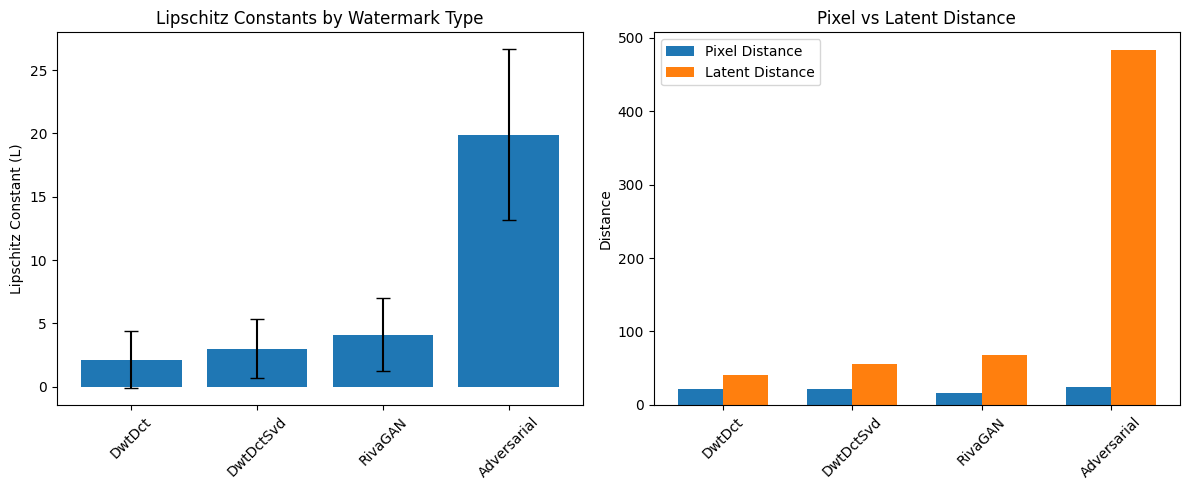

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = list(baseline_results.keys()) + ['Adversarial']
L_means = [baseline_results[k]['L_mean'] for k in baseline_results.keys()] + [adversarial_results['L_mean']]
L_stds = [baseline_results[k]['L_std'] for k in baseline_results.keys()] + [adversarial_results['L_std']]

axes[0].bar(methods, L_means, yerr=L_stds, capsize=5)
axes[0].set_ylabel('Lipschitz Constant (L)')
axes[0].set_title('Lipschitz Constants by Watermark Type')
axes[0].tick_params(axis='x', rotation=45)

pixel_means = [baseline_results[k]['pixel_dist_mean'] for k in baseline_results.keys()] + [adversarial_results['pixel_dist_mean']]
latent_means = [baseline_results[k]['latent_dist_mean'] for k in baseline_results.keys()] + [adversarial_results['latent_dist_mean']]

x = np.arange(len(methods))
width = 0.35
axes[1].bar(x - width/2, pixel_means, width, label='Pixel Distance')
axes[1].bar(x + width/2, latent_means, width, label='Latent Distance')
axes[1].set_ylabel('Distance')
axes[1].set_title('Pixel vs Latent Distance')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lipschitz_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

In [17]:
import json

results_summary = {
    'baseline': baseline_results,
    'adversarial': adversarial_results,
    'violation_ratio': ratio,
    'property_violated': bool(ratio > 10) # Convert np.bool_ to Python bool
}

with open(os.path.join(output_dir, 'lipschitz_results.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f'\nResults saved to {output_dir}')


Results saved to /content/drive/MyDrive/lipschitz_results/
